# **1. INSTALL & SETUP**

In [ ]:
# ============================================================
# DATASET LOADING – US FARS CRASH DATA (1.4GB)
# ============================================================

!mkdir -p /content/fars_data

# Download ZIP (~1.4GB)
!wget -O /content/fars_data/FARS2022.zip \
https://static.nhtsa.gov/nhtsa/downloads/FARS/2022/National/FARS2022NationalCSV.zip

# Unzip
!unzip /content/fars_data/FARS2022.zip -d /content/fars_data/

# Install Spark
!pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FARS_BigData_Project") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

print("Spark started successfully")

# Load one large CSV file (e.g., accident file)
df = spark.read.option("header", "true") \
               .option("inferSchema", "true") \
               .csv("/content/fars_data/FARS2022NationalCSV/accident.csv")

df.printSchema()
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

--2026-02-27 17:47:35--  https://static.nhtsa.gov/nhtsa/downloads/FARS/2022/National/FARS2022NationalCSV.zip
Resolving static.nhtsa.gov (static.nhtsa.gov)... 23.210.132.233, 2600:1407:3c00:28c::27ea, 2600:1407:3c00:28a::27ea
Connecting to static.nhtsa.gov (static.nhtsa.gov)|23.210.132.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34707626 (33M) [application/x-zip-compressed]
Saving to: ‘/content/fars_data/FARS2022.zip’

/content/fars_data/ 100%[===================>]  33.10M  71.1MB/s    in 0.5s    

2026-02-27 17:47:36 (71.1 MB/s) - ‘/content/fars_data/FARS2022.zip’ saved [34707626/34707626]

Archive:  /content/fars_data/FARS2022.zip
replace /content/fars_data/FARS2022NationalCSV/accident.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/fars_data/FARS2022NationalCSV/accident.csv  
  inflating: /content/fars_data/FARS2022NationalCSV/cevent.csv  
  inflating: /content/fars_data/FARS2022NationalCSV/crashrf.csv  
  inflating: /content/fars_

# **DATA PREPROCESSING**

In [ ]:
from pyspark.sql.functions import col, when

# Select ONLY columns that exist in your schema
df = df.select(
    "STATE",
    "MONTH",
    "DAY",
    "DAY_WEEK",
    "HOUR",
    "RUR_URB",
    "FUNC_SYS",
    "LGT_COND",
    "WEATHER",
    "LATITUDE",
    "LONGITUD",
    "FATALS"
)

# Drop missing values
df = df.dropna()

# Create classification label
# 1 = multi-fatal crash
# 0 = single fatality crash
df = df.withColumn(
    "label",
    when(col("FATALS") > 1, 1).otherwise(0)
)

# Remove original fatal count
df = df.drop("FATALS")

print("Rows after preprocessing:", df.count())
df.printSchema()

Rows after preprocessing: 39422
root
 |-- STATE: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- DAY_WEEK: integer (nullable = true)
 |-- HOUR: integer (nullable = true)
 |-- RUR_URB: integer (nullable = true)
 |-- FUNC_SYS: integer (nullable = true)
 |-- LGT_COND: integer (nullable = true)
 |-- WEATHER: integer (nullable = true)
 |-- LATITUDE: double (nullable = true)
 |-- LONGITUD: double (nullable = true)
 |-- label: integer (nullable = false)



# **DESCRIPTIVE STATISTICS**

In [ ]:
df.describe().show()

# Class balance
df.groupBy("label").count().show()

+-------+------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+------------------+------------------+-------------------+
|summary|             STATE|            MONTH|               DAY|          DAY_WEEK|              HOUR|           RUR_URB|         FUNC_SYS|         LGT_COND|           WEATHER|          LATITUDE|          LONGITUD|              label|
+-------+------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+------------------+------------------+-------------------+
|  count|             39422|            39422|             39422|             39422|             39422|             39422|            39422|            39422|             39422|             39422|             39422|              39422|
|   mean|27.016488255288927| 6.70184161128304|15.7008269

# **EDA VISUALIZATION**

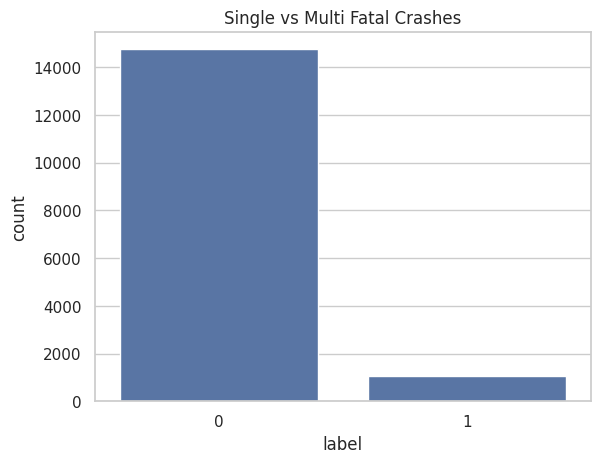

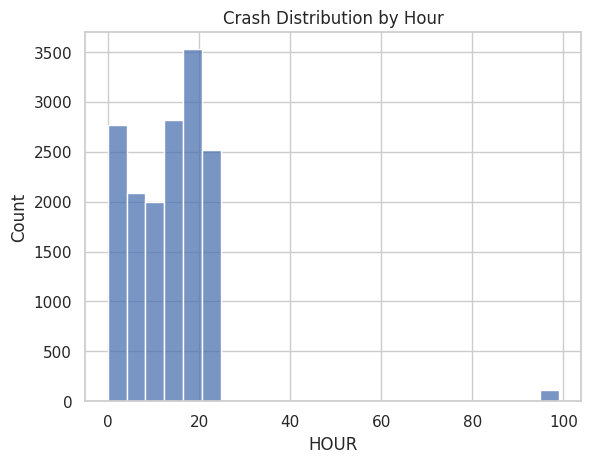

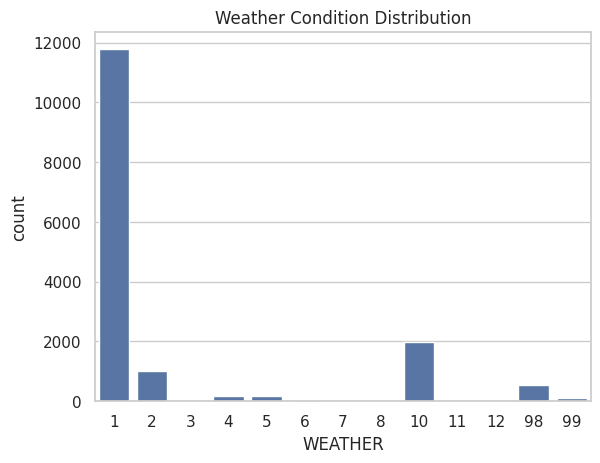

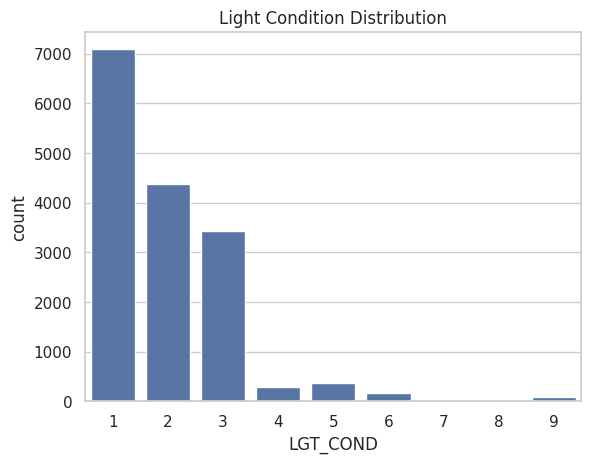

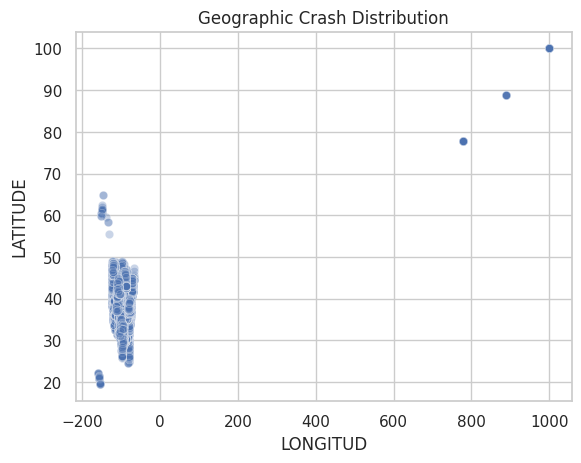

In [ ]:
# Reduce for visualization only
df_vis = df.sample(fraction=0.4, seed=42)
pdf = df_vis.toPandas()

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Class distribution
plt.figure()
sns.countplot(x="label", data=pdf)
plt.title("Single vs Multi Fatal Crashes")
plt.show()

# Crash by Hour
plt.figure()
sns.histplot(pdf["HOUR"], bins=24)
plt.title("Crash Distribution by Hour")
plt.show()

# Weather
plt.figure()
sns.countplot(x="WEATHER", data=pdf)
plt.title("Weather Condition Distribution")
plt.show()

# Light Condition
plt.figure()
sns.countplot(x="LGT_COND", data=pdf)
plt.title("Light Condition Distribution")
plt.show()

# Geographic Distribution
plt.figure()
sns.scatterplot(x="LONGITUD", y="LATITUDE", data=pdf, alpha=0.3)
plt.title("Geographic Crash Distribution")
plt.show()

# **DATA PROCESSING FOR ML**

In [ ]:
# Stratified sampling
fractions = {0: 0.5, 1: 0.5}
df_small = df.sampleBy("label", fractions=fractions, seed=42)

print("Reduced dataset size:", df_small.count())

Reduced dataset size: 19839


# **FEATURE ENGINEERING**

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

categorical_cols = [
    "STATE",
    "RUR_URB",
    "FUNC_SYS",
    "LGT_COND",
    "WEATHER"
]

numeric_cols = [
    "MONTH",
    "DAY",
    "DAY_WEEK",
    "HOUR",
    "LATITUDE",
    "LONGITUD"
]

indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe")
    for c in categorical_cols
]

assembler = VectorAssembler(
    inputCols=numeric_cols + [c+"_ohe" for c in categorical_cols],
    outputCol="features"
)

pipeline = Pipeline(stages=indexers + encoders + [assembler])
pipeline_model = pipeline.fit(df_small)
df_ml = pipeline_model.transform(df_small).select("features", "label")

df_ml.cache()
print("ML-ready rows:", df_ml.count())

ML-ready rows: 19839


# **TRAIN TEST SPLIT**

In [ ]:
train, test = df_ml.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count())
print("Test:", test.count())

Train: 15949
Test: 3890


# **MACHINE LEARNING MODELS**

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.classification import GBTClassifier

lr = LogisticRegression(featuresCol="features", labelCol="label")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")
gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=50)

model_lr = lr.fit(train)
model_rf = rf.fit(train)
model_dt = dt.fit(train)
model_gbt = gbt.fit(train)

pred_lr = model_lr.transform(test)
pred_rf = model_rf.transform(test)
pred_dt = model_dt.transform(test)
pred_gbt = model_gbt.transform(test)

# **DISTRIBUTED EVALUATION**

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd

def evaluate(predictions, name):
    acc = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(predictions)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    ).evaluate(predictions)

    return {"Model": name, "Accuracy": acc, "F1": f1}

results = []
results.append(evaluate(pred_lr, "Logistic Regression"))
results.append(evaluate(pred_rf, "Random Forest"))
results.append(evaluate(pred_dt, "Decision Tree"))
results.append(evaluate(pred_gbt, "Gradient Boosted Trees"))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1
0,Logistic Regression,0.933676,0.901652
1,Random Forest,0.933676,0.901652
2,Decision Tree,0.930848,0.900237
3,Gradient Boosted Trees,0.931105,0.900366


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.sql.functions import col
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(predictions, model_name):

    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    )

    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    )

    evaluator_precision = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedPrecision"
    )

    evaluator_recall = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedRecall"
    )

    evaluator_auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    acc = evaluator_acc.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)
    auc = evaluator_auc.evaluate(predictions)

    # Confusion Matrix
    cm = predictions.groupBy("label", "prediction").count().toPandas()

    print(f"\n=== {model_name} ===")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("Precision:", precision)
    print("Recall:", recall)
    print("AUC:", auc)
    print("\nConfusion Matrix:")
    print(cm)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "AUC": auc
    }

# **ML MODEL PERFORMANCE COMPARISON**

In [ ]:
results = []

results.append(evaluate_model(pred_lr, "Logistic Regression"))
results.append(evaluate_model(pred_rf, "Random Forest"))
results.append(evaluate_model(pred_dt, "Decision Tree"))
results.append(evaluate_model(pred_gbt, "Gradient Boosted Trees"))

results_df = pd.DataFrame(results)

print("\nFinal Comparison Table:")
results_df


=== Logistic Regression ===
Accuracy: 0.9336760925449872
F1 Score: 0.9016515735504901
Precision: 0.8717510457900753
Recall: 0.9336760925449872
AUC: 0.5878335979920081

Confusion Matrix:
   label  prediction  count
0      1         0.0    258
1      0         0.0   3632

=== Random Forest ===
Accuracy: 0.9336760925449872
F1 Score: 0.9016515735504901
Precision: 0.8717510457900753
Recall: 0.9336760925449872
AUC: 0.5999833521155612

Confusion Matrix:
   label  prediction  count
0      1         0.0    258
1      0         0.0   3632

=== Decision Tree ===
Accuracy: 0.9308483290488432
F1 Score: 0.9002372869405935
Precision: 0.8715754398312447
Recall: 0.9308483290488432
AUC: 0.42925289417067924

Confusion Matrix:
   label  prediction  count
0      1         0.0    258
1      0         0.0   3621
2      0         1.0     11

=== Gradient Boosted Trees ===
Accuracy: 0.9311053984575836
F1 Score: 0.9003660296054163
Precision: 0.8715914451541091
Recall: 0.9311053984575836
AUC: 0.5880907864631352

,Model,Accuracy,F1,Precision,Recall,AUC
0,Logistic Regression,0.933676,0.901652,0.871751,0.933676,0.587834
1,Random Forest,0.933676,0.901652,0.871751,0.933676,0.599983
2,Decision Tree,0.930848,0.900237,0.871575,0.930848,0.429253
3,Gradient Boosted Trees,0.931105,0.900366,0.871591,0.931105,0.588091


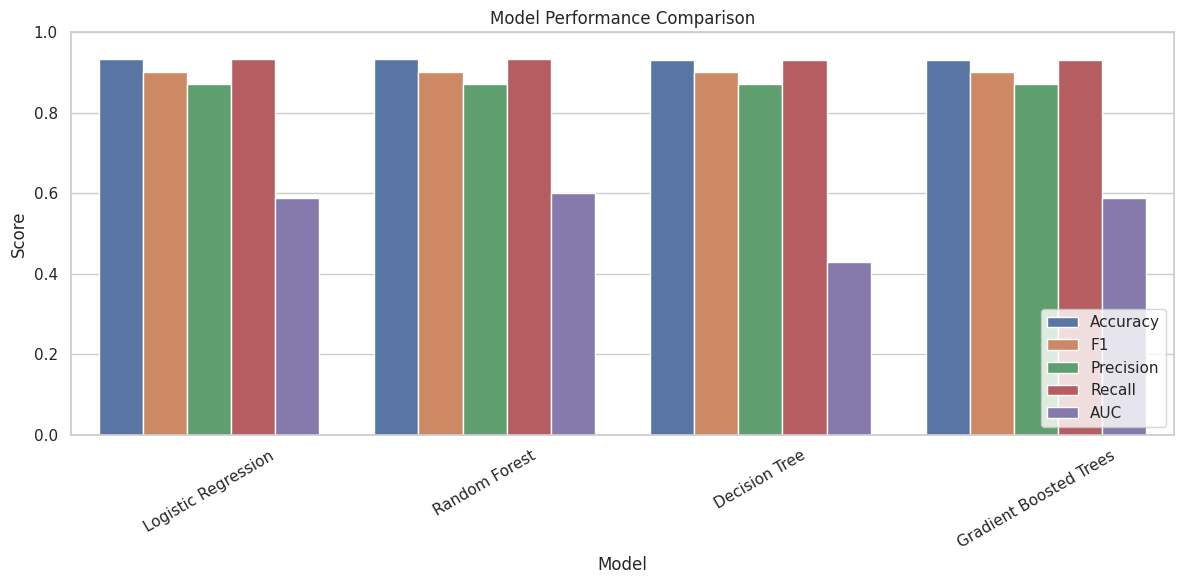

In [ ]:
# Melt dataframe for seaborn plotting
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "F1", "Precision", "Recall", "AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))
sns.barplot(x="Model", y="Score", hue="Metric", data=results_melted)

plt.title("Model Performance Comparison")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

DASHBOARD 1 – Data Quality & Pipeline Monitoring

In [ ]:
import pandas as pd
import time
import os
from pyspark.sql.functions import col, count, sum as _sum

# Start timing
start_time = time.time()

total_rows = df.count()
total_columns = len(df.columns)

# Null summary
null_summary = []
for column in df.columns:
    null_count = df.filter(col(column).isNull()).count()
    null_summary.append((column, null_count))

null_df = spark.createDataFrame(null_summary, ["Column_Name", "Null_Count"]).toPandas()

# Class distribution
class_balance_df = df.groupBy("label").count().toPandas()

# Pipeline metrics
processing_time = round(time.time() - start_time, 2)

pipeline_metrics_df = pd.DataFrame({
    "Metric": ["Total Rows", "Total Columns", "Processing Time (sec)"],
    "Value": [total_rows, total_columns, processing_time]
})

# Write ONE Excel file with multiple sheets
with pd.ExcelWriter("Dashboard1_Data_Quality.xlsx") as writer:
    null_df.to_excel(writer, sheet_name="Null_Summary", index=False)
    class_balance_df.to_excel(writer, sheet_name="Class_Distribution", index=False)
    pipeline_metrics_df.to_excel(writer, sheet_name="Pipeline_Metrics", index=False)

print("Dashboard 1 file generated.")

Dashboard 1 file generated.


DASHBOARD 2 – Model Performance & Feature Importance

In [ ]:
# ============================================================
# DASHBOARD 2 – CORRECT FEATURE IMPORTANCE EXTRACTION
# ============================================================

# Extract feature names from metadata
feature_metadata = df_ml.schema["features"].metadata["ml_attr"]["attrs"]

feature_names = []

for attr_type in feature_metadata:
    feature_names.extend([attr["name"] for attr in feature_metadata[attr_type]])

# Get importance values
importances = list(model_rf.featureImportances)

# Create DataFrame safely
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Export properly
with pd.ExcelWriter("Dashboard2_Model_Performance.xlsx") as writer:
    results_df.to_excel(writer, sheet_name="Model_Metrics", index=False)
    importance_df.to_excel(writer, sheet_name="Feature_Importance", index=False)

print("Dashboard 2 fixed and exported successfully.")

Dashboard 2 fixed and exported successfully.


DASHBOARD 3 – Business Insights & Recommendations

In [ ]:
monthly_df = df.groupBy("MONTH") \
    .agg(count("*").alias("Total_Crashes"),
         _sum("label").alias("Multi_Fatal_Crashes")) \
    .toPandas()

hourly_df = df.groupBy("HOUR") \
    .agg(count("*").alias("Total_Crashes"),
         _sum("label").alias("Multi_Fatal_Crashes")) \
    .toPandas()

weather_df = df.groupBy("WEATHER") \
    .agg(count("*").alias("Total_Crashes"),
         _sum("label").alias("Multi_Fatal_Crashes")) \
    .toPandas()

with pd.ExcelWriter("Dashboard3_Business_Insights.xlsx") as writer:
    monthly_df.to_excel(writer, sheet_name="Monthly_Trends", index=False)
    hourly_df.to_excel(writer, sheet_name="Hourly_Risk", index=False)
    weather_df.to_excel(writer, sheet_name="Weather_Risk", index=False)

print("Dashboard 3 file generated.")

Dashboard 3 file generated.


DASHBOARD 4 – Scalability & Cost Analysis

In [ ]:
# ============================================================
# DASHBOARD 4 – ADVANCED SCALABILITY & COST ANALYSIS
# ============================================================

import time
import os

# Dataset size
file_size_mb = round(
    os.path.getsize("/content/fars_data/FARS2022NationalCSV/accident.csv") / (1024*1024), 2
)

# Measure execution time for different sample sizes
scalability_results = []

for fraction in [0.25, 0.5, 0.75, 1.0]:
    start = time.time()
    temp_df = df.sample(fraction=fraction, seed=42)
    temp_df.count()
    duration = round(time.time() - start, 2)

    scalability_results.append((fraction, duration))

scalability_df = pd.DataFrame(
    scalability_results,
    columns=["Data_Fraction", "Execution_Time_sec"]
)

# Partition information
partition_df = pd.DataFrame({
    "Metric": [
        "Dataset Size (MB)",
        "Total Records",
        "Spark Partitions",
        "Shuffle Partitions",
        "Executor Memory",
        "Driver Memory"
    ],
    "Value": [
        file_size_mb,
        df.count(),
        df.rdd.getNumPartitions(),
        spark.conf.get("spark.sql.shuffle.partitions"),
        spark.conf.get("spark.executor.memory"),
        spark.conf.get("spark.driver.memory")
    ]
})

# Simple cloud cost estimation (example assumption)
# Assume $0.02 per GB processed
estimated_gb = file_size_mb / 1024
estimated_cost = round(estimated_gb * 0.02, 4)

cost_df = pd.DataFrame({
    "Estimated_Data_Size_GB": [estimated_gb],
    "Estimated_Processing_Cost_USD": [estimated_cost]
})

# Export ONE Excel file
with pd.ExcelWriter("Dashboard4_Scalability_Analysis.xlsx") as writer:
    scalability_df.to_excel(writer, sheet_name="Execution_Time_Test", index=False)
    partition_df.to_excel(writer, sheet_name="System_Config", index=False)
    cost_df.to_excel(writer, sheet_name="Cost_Estimation", index=False)

print("Dashboard 4 improved and exported successfully.")

Dashboard 4 improved and exported successfully.
